In [ ]:
!pip install dagster dagster-webserver pyarrow

In [ ]:
%%writefile pipeline.py
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dagster import asset, Definitions, define_asset_job, AssetExecutionContext
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import pickle
import os

@asset
def load_data():
    df = pd.read_csv("/content/taxi_trips_2024.csv")
    df.columns = [c.replace(" ", "_").lower() for c in df.columns]
    df = df.dropna(subset=['trip_seconds', 'trip_miles', 'fare', 'trip_total'])
    return df

@asset
def preprocess_data(load_data):
    df = load_data
    features = ['trip_seconds', 'trip_miles', 'tips', 'tolls', 'extras']
    target = 'trip_total'

    X = df[features]
    y = df[target]

    return train_test_split(X, y, test_size=0.2, random_state=42)

@asset
def generate_eda(load_data):
    df = load_data

    if not os.path.exists("eda_plots"):
        os.makedirs("eda_plots")

    # Fare Distribution
    plt.figure(figsize=(5, 4))
    sns.histplot(df['trip_total'], bins=50)
    plt.title("Distribution of Trip Totals")
    plt.savefig("eda_plots/trip_total_dist.png")
    plt.close()

    # Trip Miles vs Fare
    plt.figure(figsize=(5, 4))
    sns.scatterplot(x=df['trip_miles'], y=df['trip_total'])
    plt.title("Trip Miles vs Fare")
    plt.savefig("eda_plots/miles_vs_fare.png")
    plt.close()

    return "EDA plots saved to /eda_plots folder"

@asset
def train_decision_tree(preprocess_data):
    X_train, X_test, y_train, y_test = preprocess_data
    model = DecisionTreeRegressor(max_depth=5)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    score = mean_absolute_error(y_test, preds)
    return {"model": model, "mae": score, "name": "Decision Tree"}

@asset
def train_random_forest(preprocess_data):
    X_train, X_test, y_train, y_test = preprocess_data
    model = RandomForestRegressor(n_estimators=50, max_depth=10)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    score = mean_absolute_error(y_test, preds)
    return {"model": model, "mae": score, "name": "Random Forest"}

@asset
def train_linear_regression(preprocess_data):
    X_train, X_test, y_train, y_test = preprocess_data
    model = LinearRegression()
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    score = mean_absolute_error(y_test, preds)
    return {"model": model, "mae": score, "name": "Linear Regression"}

@asset
def compare_models(train_decision_tree, train_random_forest, train_linear_regression):
    results = [train_decision_tree, train_random_forest, train_linear_regression]

    best_model = min(results, key=lambda x: x['mae'])

    report = f"Model Comparison Report:\n"
    for res in results:
        report += f"{res['name']}: MAE = {res['mae']:.4f}\n"

    report += f"\nWINNER: {best_model['name']} with MAE {best_model['mae']:.4f}"
    with open("model_report.txt", "w") as f:
        f.write(report)

    print(report)
    return report

defs = Definitions(
    assets=[
        load_data,
        preprocess_data,
        generate_eda,
        train_decision_tree,
        train_random_forest,
        train_linear_regression,
        compare_models
    ]
)

Overwriting pipeline.py


In [ ]:
get_ipython().system_raw('dagster dev -f pipeline.py -h 0.0.0.0 -p 3000 &')
print("Dagster is starting in the background...")

Dagster is starting in the background...


In [ ]:
from google.colab import output
import time

time.sleep(5)
print("Click the link below to open Dagster:")
output.serve_kernel_port_as_window(3000)

Click the link below to open Dagster:
Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

--- MODEL COMPARISON RESULTS ---
Model Comparison Report:
Decision Tree: MAE = 5.6439
Random Forest: MAE = 2.5441
Linear Regression: MAE = 4.2328

WINNER: Random Forest with MAE 2.5441

--- EDA VISUALIZATIONS ---
Displaying: trip_total_dist.png


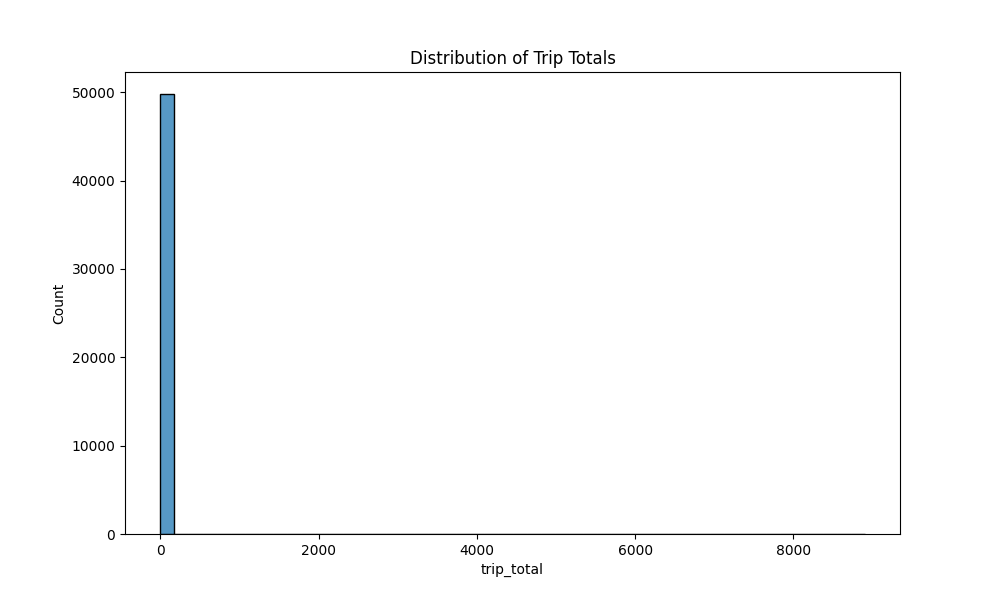

Displaying: miles_vs_fare.png


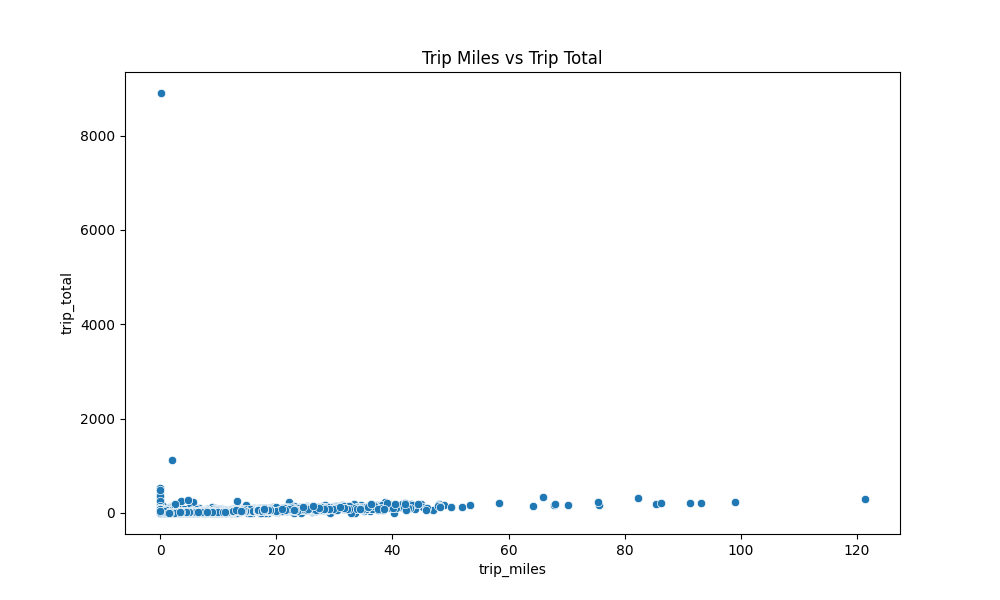

In [ ]:
from IPython.display import Image, display

print("--- MODEL COMPARISON RESULTS ---")
try:
    with open("model_report.txt", "r") as f:
        print(f.read())
except FileNotFoundError:
    print("Error: model_report.txt not found. Did the pipeline run successfully?")

print("\n--- EDA VISUALIZATIONS ---")
import os
if os.path.exists("eda_plots"):
    for img_file in os.listdir("eda_plots"):
        if img_file.endswith(".png"):
            print(f"Displaying: {img_file}")
            display(Image(filename=f"eda_plots/{img_file}"))
else:
    print("Error: EDA plots not found.")